## 1. Configuration & Seeding

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import os
import optuna
from optuna.samplers import TPESampler
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Ensure GPU is used if available
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("✅ GPU detected. Using CUDA for training.")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ GPU not detected. Using CPU for training.")

⚠️ GPU not detected. Using CPU for training.


In [3]:
def seed_everything(seed=42):
    """Set seeds for reproducibility"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Processing on: {DEVICE}")

# Fixed Settings
BATCH_SIZE = 64
N_TRIALS = 20  # Number of Optuna trials
FINAL_EPOCHS = 50  # Epochs for final training

print(f"Batch Size: {BATCH_SIZE}")
print(f"Optuna Trials: {N_TRIALS}")
print(f"Final Training Epochs: {FINAL_EPOCHS}")

✅ Processing on: cpu
Batch Size: 64
Optuna Trials: 20
Final Training Epochs: 50


## 2. Data Loading & Feature Engineering

In [4]:
def create_advanced_features(df):
    """Create advanced engineered features"""
    df = df.copy()
    
    # Age-related features
    df['age_years_ratio'] = df['founder_age'] / (df['years_with_startup'] + 1)
    
    # Business metrics
    df['annual_revenue_estimate'] = df['monthly_revenue_generated'] * 12
    
    # Experience ratios
    df['tenure_ratio'] = df['years_with_startup'] / (df['founder_age'] + 1)
    
    # Polynomial features for key metrics
    df['revenue_sq'] = df['monthly_revenue_generated'] ** 2
    df['age_sq'] = df['founder_age'] ** 2
    
    return df

print("[1/7] Loading dropped column data...")
try:
    # Load full training data (not the 20% sample)
    train_df_full = pd.read_csv('../dataset/train_dropped_column.csv')
    test_df = pd.read_csv('../dataset/test_dropped_column.csv')
    print(f"✓ Full training data loaded: {train_df_full.shape}")
    print(f"✓ Test data loaded: {test_df.shape}")
except FileNotFoundError:
    print("❌ Error: Dropped column data files not found.")
    raise

# Apply feature engineering
train_df_full = create_advanced_features(train_df_full)
test_df = create_advanced_features(test_df)
print("✓ Feature engineering completed")

# Split into 80% for training/validation and 20% for final evaluation
from sklearn.model_selection import train_test_split

X_full = train_df_full.drop(['retention_status', 'founder_id'], axis=1)
y_full = train_df_full['retention_status']

X_train, X_eval, y_train, y_eval = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)

print(f"\n✓ Data split complete:")
print(f"  - Training/Validation set: {X_train.shape[0]} samples (80%)")
print(f"  - Evaluation set: {X_eval.shape[0]} samples (20%)")
print(f"  - Test set: {test_df.shape[0]} samples")
print(f"\n✓ Training set target distribution:\n{y_train.value_counts()}")
print(f"\n✓ Evaluation set target distribution:\n{y_eval.value_counts()}")


[1/7] Loading dropped column data...
✓ Full training data loaded: (59608, 23)
✓ Test data loaded: (14900, 22)
✓ Feature engineering completed
✓ Full training data loaded: (59608, 23)
✓ Test data loaded: (14900, 22)
✓ Feature engineering completed

✓ Data split complete:
  - Training/Validation set: 47686 samples (80%)
  - Evaluation set: 11922 samples (20%)
  - Test set: 14900 samples

✓ Training set target distribution:
retention_status
Stayed    25011
Left      22675
Name: count, dtype: int64

✓ Evaluation set target distribution:
retention_status
Stayed    6253
Left      5669
Name: count, dtype: int64

✓ Data split complete:
  - Training/Validation set: 47686 samples (80%)
  - Evaluation set: 11922 samples (20%)
  - Test set: 14900 samples

✓ Training set target distribution:
retention_status
Stayed    25011
Left      22675
Name: count, dtype: int64

✓ Evaluation set target distribution:
retention_status
Stayed    6253
Left      5669
Name: count, dtype: int64


In [5]:
print("[2/7] Preparing features and target...")

# Use the 80% training split for model training
X = X_train.copy()
y = y_train.copy()

# Store test IDs and features
test_ids = test_df['founder_id'].copy()
X_test = test_df.drop(['founder_id'], axis=1)

# Store evaluation set for final metrics
X_eval_final = X_eval.copy()
y_eval_final = y_eval.copy()

print(f"✓ Training features shape: {X.shape}")
print(f"✓ Evaluation features shape: {X_eval_final.shape}")
print(f"✓ Test features shape: {X_test.shape}")


[2/7] Preparing features and target...
✓ Training features shape: (47686, 26)
✓ Evaluation features shape: (11922, 26)
✓ Test features shape: (14900, 26)


## 3. Preprocessing (Embeddings + Scaling)

In [6]:
print("[3/7] Encoding and scaling features...")

# Identify categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"✓ Categorical columns: {len(cat_cols)}")
print(f"✓ Numerical columns: {len(num_cols)}")
print(f"\nCategorical: {cat_cols}")

# Encode categorical variables and calculate embedding dimensions
cat_dims = []
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Combine train, eval, and test for consistent encoding
    full_data = pd.concat([X[col], X_eval_final[col], X_test[col]], axis=0).astype(str)
    le.fit(full_data)
    
    X[col] = le.transform(X[col].astype(str))
    X_eval_final[col] = le.transform(X_eval_final[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le
    
    num_classes = len(le.classes_)
    emb_dim = min(50, (num_classes + 1) // 2)
    cat_dims.append((num_classes, emb_dim))
    print(f"  {col}: {num_classes} classes -> embedding dim {emb_dim}")

print("\n✓ Categorical encoding completed")


[3/7] Encoding and scaling features...
✓ Categorical columns: 15
✓ Numerical columns: 11

Categorical: ['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility']
  founder_gender: 2 classes -> embedding dim 1
  founder_role: 5 classes -> embedding dim 3
  work_life_balance_rating: 4 classes -> embedding dim 2
  venture_satisfaction: 4 classes -> embedding dim 2
  startup_performance_rating: 4 classes -> embedding dim 2
  working_overtime: 2 classes -> embedding dim 1
  education_background: 5 classes -> embedding dim 3
  personal_status: 3 classes -> embedding dim 2
  startup_stage: 3 classes -> embedding dim 2
  venture_satisfaction: 4 classes -> embedding dim 2
  startup_performance_rating: 4 classes -> embedding dim 2
  

In [7]:
# Scale numerical features
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
X_eval_final[num_cols] = scaler.transform(X_eval_final[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("✓ Numerical scaling completed")


✓ Numerical scaling completed


In [8]:
# Encode target variable
target_le = LabelEncoder()
y_encoded = target_le.fit_transform(y)
y_eval_encoded = target_le.transform(y_eval_final)
num_classes_target = len(target_le.classes_)

print(f"✓ Target classes: {target_le.classes_}")
print(f"✓ Number of classes: {num_classes_target}")

# Compute class weights for balanced training
class_weights = compute_class_weight('balanced', classes=np.unique(y_encoded), y=y_encoded)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"✓ Class weights: {class_weights}")

# Prepare numpy arrays for training
X_cat = X[cat_cols].values
X_num = X[num_cols].values

# Prepare numpy arrays for evaluation set
X_eval_cat = X_eval_final[cat_cols].values
X_eval_num = X_eval_final[num_cols].values

# Prepare numpy arrays for test set
X_test_cat = X_test[cat_cols].values
X_test_num = X_test[num_cols].values

print(f"\n✓ Arrays prepared:")
print(f"  Training: {X_cat.shape[0]} samples")
print(f"  Evaluation: {X_eval_cat.shape[0]} samples")
print(f"  Test: {X_test_cat.shape[0]} samples")


✓ Target classes: ['Left' 'Stayed']
✓ Number of classes: 2
✓ Class weights: [1.05151047 0.95330055]

✓ Arrays prepared:
  Training: 47686 samples
  Evaluation: 11922 samples
  Test: 14900 samples


## 4. Define Model Architecture

In [9]:
class AdvancedTabularDataset(Dataset):
    """Custom Dataset for tabular data with categorical and numerical features"""
    def __init__(self, x_cat, x_num, y=None):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_num = torch.tensor(x_num, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None
    
    def __len__(self):
        return len(self.x_cat)
    
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_cat[idx], self.x_num[idx], self.y[idx]
        return self.x_cat[idx], self.x_num[idx]

print("✓ Dataset class defined")

✓ Dataset class defined


In [10]:
class DynamicTabularModel(nn.Module):
    """Advanced Neural Network with embeddings for categorical features"""
    def __init__(self, cat_dims, num_dim, output_dim, 
                 l1_size, l2_size, l3_size, 
                 emb_dropout, hidden_dropout):
        super(DynamicTabularModel, self).__init__()
        
        # Embedding layers for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(n, d) for n, d in cat_dims
        ])
        self.emb_dropout = nn.Dropout(emb_dropout)
        total_emb_dim = sum([d for _, d in cat_dims])
        
        # Input batch normalization
        input_dim = total_emb_dim + num_dim
        self.bn0 = nn.BatchNorm1d(num_dim)
        
        # Layer 1
        self.fc1 = nn.Linear(input_dim, l1_size)
        self.bn1 = nn.BatchNorm1d(l1_size)
        self.act1 = nn.GELU()
        self.drop1 = nn.Dropout(hidden_dropout)
        
        # Layer 2
        self.fc2 = nn.Linear(l1_size, l2_size)
        self.bn2 = nn.BatchNorm1d(l2_size)
        self.act2 = nn.GELU()
        self.drop2 = nn.Dropout(hidden_dropout)
        
        # Layer 3
        self.fc3 = nn.Linear(l2_size, l3_size)
        self.bn3 = nn.BatchNorm1d(l3_size)
        self.act3 = nn.GELU()
        self.drop3 = nn.Dropout(hidden_dropout / 2)
        
        # Output layer
        self.output = nn.Linear(l3_size, output_dim)
        
    def forward(self, x_cat, x_num):
        # Process embeddings
        emb_list = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_emb = self.emb_dropout(torch.cat(emb_list, dim=1))
        
        # Process numerical features
        x_num = self.bn0(x_num)
        
        # Concatenate all features
        x = torch.cat([x_emb, x_num], dim=1)
        
        # Forward through layers
        x = self.drop1(self.act1(self.bn1(self.fc1(x))))
        x = self.drop2(self.act2(self.bn2(self.fc2(x))))
        x = self.drop3(self.act3(self.bn3(self.fc3(x))))
        
        return self.output(x)

print("✓ Model architecture defined")

✓ Model architecture defined


## 5. Optuna Hyperparameter Tuning

In [11]:
print(f"[4/7] Starting Optuna Tuning ({N_TRIALS} Trials)...")
print("-" * 80)

def objective(trial):
    """FAST + PRUNED Optuna objective function"""

    # --- Lightweight search space (MUCH FASTER) ---
    l1_size = trial.suggest_categorical('l1_size', [64, 128, 256])
    l2_size = trial.suggest_categorical('l2_size', [32, 64, 128])
    l3_size = trial.suggest_categorical('l3_size', [16, 32, 64])

    emb_dropout = trial.suggest_float('emb_dropout', 0.1, 0.4)
    hidden_dropout = trial.suggest_float('hidden_dropout', 0.1, 0.4)

    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    # 2-fold CV (much faster, still reliable)
    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
    scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_num, y_encoded)):

        # Dataset & loaders
        train_ds = AdvancedTabularDataset(X_cat[train_idx], X_num[train_idx], y_encoded[train_idx])
        val_ds = AdvancedTabularDataset(X_cat[val_idx], X_num[val_idx], y_encoded[val_idx])

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

        # Model
        model = DynamicTabularModel(
            cat_dims, X_num.shape[1], num_classes_target,
            l1_size, l2_size, l3_size, emb_dropout, hidden_dropout
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        # --- FAST training: only 8 epochs ---
        for epoch in range(8):
            model.train()
            for c, n, y_batch in train_loader:
                c, n, y_batch = c.to(DEVICE), n.to(DEVICE), y_batch.to(DEVICE)

                optimizer.zero_grad()
                loss = criterion(model(c, n), y_batch)
                loss.backward()
                optimizer.step()

            # Validate each epoch (for pruning)
            model.eval()
            preds, labels = [], []
            with torch.no_grad():
                for c, n, y_batch in val_loader:
                    c, n = c.to(DEVICE), n.to(DEVICE)
                    p = torch.argmax(model(c, n), dim=1)
                    preds.extend(p.cpu().numpy())
                    labels.extend(y_batch.numpy())

            val_acc = accuracy_score(labels, preds)

            # Report accuracy per epoch for early pruning
            trial.report(val_acc, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        scores.append(val_acc)

    # Return mean accuracy across folds
    return np.mean(scores)

print("✓ Optimized objective function ready")


[4/7] Starting Optuna Tuning (20 Trials)...
--------------------------------------------------------------------------------
✓ Optimized objective function ready


In [12]:
 # ---- RUN OPTUNA STUDY ----
sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)

print("\n🚀 Running Optuna study...\n")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# ---- PRINT BEST PARAMETERS ----
print("\n" + "="*80)
print("🎉 BEST HYPERPARAMETERS FOUND")
print("="*80)

best_p = study.best_params
for k, v in best_p.items():
    print(f"{k}: {v}")

print("="*80)

[I 2025-12-02 22:23:50,328] A new study created in memory with name: no-name-1d312194-04ca-48f1-b0f5-087d33cfb6e3



🚀 Running Optuna study...



  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-02 22:24:24,396] Trial 0 finished with value: 0.7455227949502998 and parameters: {'l1_size': 128, 'l2_size': 32, 'l3_size': 32, 'emb_dropout': 0.3124217733388137, 'hidden_dropout': 0.10617534828874074, 'lr': 0.0044447541666908135, 'weight_decay': 0.0003142880890840109}. Best is trial 0 with value: 0.7455227949502998.
[I 2025-12-02 22:24:45,379] Trial 1 finished with value: 0.7464035565994213 and parameters: {'l1_size': 64, 'l2_size': 64, 'l3_size': 32, 'emb_dropout': 0.18764339456056545, 'hidden_dropout': 0.20990855298810754, 'lr': 0.0005954553793888993, 'weight_decay': 0.0002267398652378039}. Best is trial 1 with value: 0.7464035565994213.
[I 2025-12-02 22:24:45,379] Trial 1 finished with value: 0.7464035565994213 and parameters: {'l1_size': 64, 'l2_size': 64, 'l3_size': 32, 'emb_dropout': 0.18764339456056545, 'hidden_dropout': 0.20990855298810754, 'lr': 0.0005954553793888993, 'weight_decay': 0.0002267398652378039}. Best is trial 1 with value: 0.7464035565994213.
[I 2025-12

## 6. Final Training with Best Parameters

In [13]:
print("\n" + "=" * 80)
print("[5/7] Training Final Model with Best Params (5-Fold CV on 80% data)")
print("=" * 80)

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
test_probs_sum = np.zeros((len(X_test), num_classes_target))
eval_probs_sum = np.zeros((len(X_eval_cat), num_classes_target))
final_scores = []
fold_models = []

for fold, (train_idx, val_idx) in enumerate(skf_final.split(X_num, y_encoded)):
    print(f"\n--- Fold {fold+1}/5 ---")
    
    # Create datasets
    train_ds = AdvancedTabularDataset(X_cat[train_idx], X_num[train_idx], y_encoded[train_idx])
    val_ds = AdvancedTabularDataset(X_cat[val_idx], X_num[val_idx], y_encoded[val_idx])
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    
    # Create model with best parameters
    model = DynamicTabularModel(
        cat_dims, X_num.shape[1], num_classes_target,
        best_p['l1_size'], best_p['l2_size'], best_p['l3_size'],
        best_p['emb_dropout'], best_p['hidden_dropout']
    ).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=best_p['lr'], weight_decay=best_p['weight_decay'])
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=best_p['lr']*10, 
        steps_per_epoch=len(train_loader), 
        epochs=FINAL_EPOCHS
    )
    
    best_val_acc = 0
    best_state = None
    patience_counter = 0
    
    # Training loop
    for epoch in range(FINAL_EPOCHS):
        model.train()
        train_loss = 0
        for c, n, y_batch in train_loader:
            c, n, y_batch = c.to(DEVICE), n.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(c, n), y_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
        
        # Validation
        model.eval()
        preds, labels = [], []
        with torch.no_grad():
            for c, n, y_batch in val_loader:
                c, n = c.to(DEVICE), n.to(DEVICE)
                p = torch.argmax(model(c, n), dim=1)
                preds.extend(p.cpu().numpy())
                labels.extend(y_batch.numpy())
        
        val_acc = accuracy_score(labels, preds)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{FINAL_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | Best: {best_val_acc:.4f}")
    
    print(f"✓ Fold {fold+1} Best Validation Accuracy: {best_val_acc:.4f}")
    final_scores.append(best_val_acc)
    
    # Load best model
    model.load_state_dict(best_state)
    model.eval()
    
    # Predict on evaluation set (20% holdout)
    eval_ds = AdvancedTabularDataset(X_eval_cat, X_eval_num)
    eval_loader = DataLoader(eval_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    
    fold_eval_probs = []
    with torch.no_grad():
        for c, n in eval_loader:
            c, n = c.to(DEVICE), n.to(DEVICE)
            probs = torch.softmax(model(c, n), dim=1)
            fold_eval_probs.append(probs.cpu().numpy())
    
    eval_probs_sum += np.concatenate(fold_eval_probs)
    
    # Predict on test set
    test_ds = AdvancedTabularDataset(X_test_cat, X_test_num)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)
    
    fold_probs = []
    with torch.no_grad():
        for c, n in test_loader:
            c, n = c.to(DEVICE), n.to(DEVICE)
            probs = torch.softmax(model(c, n), dim=1)
            fold_probs.append(probs.cpu().numpy())
    
    test_probs_sum += np.concatenate(fold_probs)
    fold_models.append(model.state_dict())

print("\n" + "=" * 80)
print(f"🏆 Cross-Validation Results (on 80% training data):")
print(f"   Average Validation Accuracy: {np.mean(final_scores):.4f} (+/- {np.std(final_scores):.4f})")
print(f"   Fold Scores: {[f'{s:.4f}' for s in final_scores]}")
print("=" * 80)



[5/7] Training Final Model with Best Params (5-Fold CV on 80% data)

--- Fold 1/5 ---
Epoch 10/50 | Train Loss: 0.5862 | Val Acc: 0.7232 | Best: 0.7488
Epoch 10/50 | Train Loss: 0.5862 | Val Acc: 0.7232 | Best: 0.7488
Epoch 20/50 | Train Loss: 0.5828 | Val Acc: 0.7521 | Best: 0.7521
Epoch 20/50 | Train Loss: 0.5828 | Val Acc: 0.7521 | Best: 0.7521
Epoch 30/50 | Train Loss: 0.5765 | Val Acc: 0.7479 | Best: 0.7555
Epoch 30/50 | Train Loss: 0.5765 | Val Acc: 0.7479 | Best: 0.7555
Epoch 40/50 | Train Loss: 0.5717 | Val Acc: 0.7344 | Best: 0.7558
Epoch 40/50 | Train Loss: 0.5717 | Val Acc: 0.7344 | Best: 0.7558
Epoch 50/50 | Train Loss: 0.5699 | Val Acc: 0.7527 | Best: 0.7558
✓ Fold 1 Best Validation Accuracy: 0.7558
Epoch 50/50 | Train Loss: 0.5699 | Val Acc: 0.7527 | Best: 0.7558
✓ Fold 1 Best Validation Accuracy: 0.7558

--- Fold 2/5 ---

--- Fold 2/5 ---
Epoch 10/50 | Train Loss: 0.5836 | Val Acc: 0.7485 | Best: 0.7519
Epoch 10/50 | Train Loss: 0.5836 | Val Acc: 0.7485 | Best: 0.7519
E

## 7. Evaluate on Holdout Set (20% of Training Data)

In [14]:
print("\n" + "=" * 80)
print("[6/7] Evaluating on Holdout Set (20% of original training data)")
print("=" * 80)

# Average predictions across folds for evaluation set
avg_eval_probs = eval_probs_sum / 5

# Get predicted classes
eval_pred_indices = np.argmax(avg_eval_probs, axis=1)
eval_pred_labels = target_le.inverse_transform(eval_pred_indices)

# Calculate metrics on evaluation set
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

eval_accuracy = accuracy_score(y_eval_final, eval_pred_labels)
print(f"\n🎯 Holdout Set Accuracy: {eval_accuracy:.4f}")

print("\n📊 Classification Report (Holdout Set):")
print(classification_report(y_eval_final, eval_pred_labels))

print("\n📈 Confusion Matrix (Holdout Set):")
cm = confusion_matrix(y_eval_final, eval_pred_labels)
print(cm)

# Save evaluation results
eval_results_df = pd.DataFrame({
    'true_label': y_eval_final.values,
    'predicted_label': eval_pred_labels,
    **{f'prob_{cls}': avg_eval_probs[:, i] for i, cls in enumerate(target_le.classes_)}
})
eval_results_df.to_csv('evaluation_set_results.csv', index=False)
print("\n✅ Saved 'evaluation_set_results.csv' with holdout set predictions")

print("=" * 80)


[6/7] Evaluating on Holdout Set (20% of original training data)

🎯 Holdout Set Accuracy: 0.7480

📊 Classification Report (Holdout Set):
              precision    recall  f1-score   support

        Left       0.73      0.75      0.74      5669
      Stayed       0.77      0.75      0.76      6253

    accuracy                           0.75     11922
   macro avg       0.75      0.75      0.75     11922
weighted avg       0.75      0.75      0.75     11922


📈 Confusion Matrix (Holdout Set):
[[4243 1426]
 [1578 4675]]
              precision    recall  f1-score   support

        Left       0.73      0.75      0.74      5669
      Stayed       0.77      0.75      0.76      6253

    accuracy                           0.75     11922
   macro avg       0.75      0.75      0.75     11922
weighted avg       0.75      0.75      0.75     11922


📈 Confusion Matrix (Holdout Set):
[[4243 1426]
 [1578 4675]]

✅ Saved 'evaluation_set_results.csv' with holdout set predictions

✅ Saved 'evaluati

## 8. Generate Test Set Predictions

In [20]:
print("\n[7/7] Generating predictions and saving results...")

# Average predictions across folds for test set
avg_test_probs = test_probs_sum / 5

# Save probability predictions
prob_df = pd.DataFrame(avg_test_probs, columns=[f'prob_{cls}' for cls in target_le.classes_])
prob_df['founder_id'] = test_ids.values
prob_df.to_csv('nn_optuna_probs.csv', index=False)
print("✅ Saved 'nn_optuna_probs.csv'")

# Create submission file
final_indices = np.argmax(avg_test_probs, axis=1)
final_labels = target_le.inverse_transform(final_indices)

submission_df = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': final_labels
})
submission_df.to_csv('submission_nn_optuna_20pca.csv', index=False)
print("✅ Saved 'submission_nn_optuna_20pca.csv'")

# Display prediction distribution
print("\nTest Set Prediction distribution:")
print(submission_df['retention_status'].value_counts())



[7/7] Generating predictions and saving results...
✅ Saved 'nn_optuna_probs.csv'
✅ Saved 'submission_nn_optuna_20pca.csv'

Test Set Prediction distribution:
retention_status
Stayed    7615
Left      7285
Name: count, dtype: int64


## 9. Visualize Results

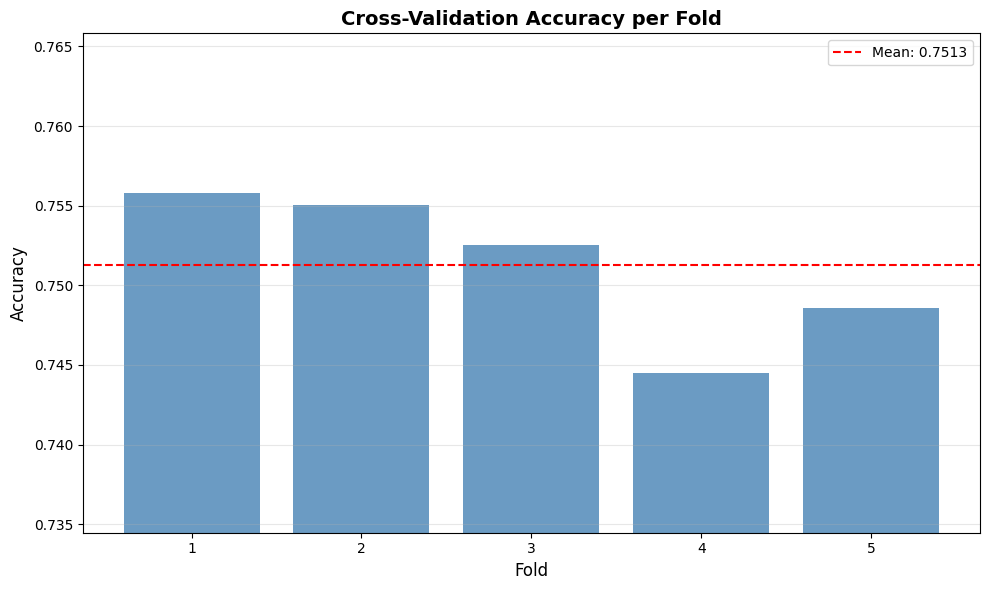

In [16]:
# Plot fold scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), final_scores, color='steelblue', alpha=0.8)
plt.axhline(y=np.mean(final_scores), color='red', linestyle='--', label=f'Mean: {np.mean(final_scores):.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation Accuracy per Fold', fontsize=14, fontweight='bold')
plt.ylim([min(final_scores) - 0.01, max(final_scores) + 0.01])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

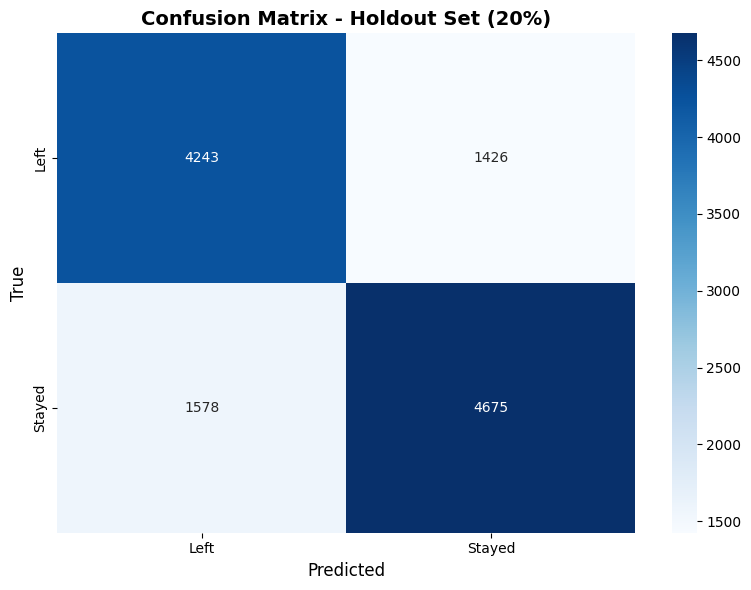

In [17]:
# Visualize confusion matrix for holdout set
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Holdout Set (20%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

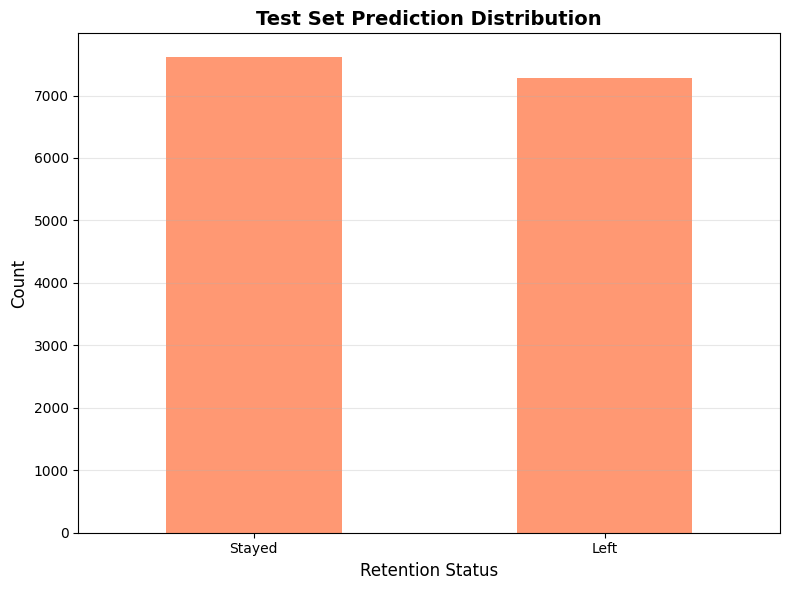

In [18]:
# Plot prediction distribution
plt.figure(figsize=(8, 6))
submission_df['retention_status'].value_counts().plot(kind='bar', color='coral', alpha=0.8)
plt.xlabel('Retention Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Test Set Prediction Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

### Data Split Strategy:
- **Training/Validation**: 80% of original training data (used for Optuna tuning and 5-fold CV)
- **Evaluation (Holdout)**: 20% of original training data (used for final metrics)
- **Test**: Separate test set for final predictions

### Model Configuration:
- **Architecture**: 3-layer neural network with embeddings for categorical features
- **Optimization**: Optuna with TPE sampler
- **Cross-Validation**: 5-fold stratified on 80% training data
- **Device**: GPU if available, otherwise CPU

### Best Hyperparameters:
See output from Optuna tuning above.

### Performance:
- **Cross-Validation**: Average accuracy across 5 folds on 80% training data
- **Holdout Set**: Final evaluation metrics on 20% unseen data
- **Test Set**: Predictions generated for submission

### Output Files:
1. `submission_nn_optuna.csv` - Final predictions for test set
2. `nn_optuna_probs.csv` - Class probabilities for test set
3. `evaluation_set_results.csv` - Predictions and probabilities for 20% holdout set

In [19]:
print("\n" + "=" * 80)
print("✅ TRAINING COMPLETE!")
print("=" * 80)
print(f"\n📊 Cross-Validation Accuracy (80% train): {np.mean(final_scores):.4f} (+/- {np.std(final_scores):.4f})")
print(f"🎯 Holdout Set Accuracy (20% eval): {eval_accuracy:.4f}")
print("\n📁 Output files:")
print("  1. submission_nn_optuna.csv - Test set predictions")
print("  2. nn_optuna_probs.csv - Test set prediction probabilities")
print("  3. evaluation_set_results.csv - Holdout set evaluation results")
print("=" * 80)


✅ TRAINING COMPLETE!

📊 Cross-Validation Accuracy (80% train): 0.7513 (+/- 0.0042)
🎯 Holdout Set Accuracy (20% eval): 0.7480

📁 Output files:
  1. submission_nn_optuna.csv - Test set predictions
  2. nn_optuna_probs.csv - Test set prediction probabilities
  3. evaluation_set_results.csv - Holdout set evaluation results
